<h1 style="color:purple;">Tutorial Networkx 1</h1>

En este cuaderno se describe la solución de tres problemas de redes mediante la biblioteca Networkx de Python:
1. Árbol de expansión mínima
2. Ruta más corta
3. Flujo máximo

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

<h2 style="color:#2E75B6;">1. Árbol de expansión mínima</h2>

**Definición:** Busca conectar todos los nodos de la red
usando el menor peso posible y sin generar ciclos.

La función objetivo es:

$$
\min \sum_{(i,j)\in T} w_{ij}
$$

donde $w_{ij}$ representa el peso de cada arista y $T$ es el árbol de expansión mínima.

Para resolver el problema se debe utilizar la función `nx.minimum_spanning_tree()`.

In [3]:
# Gráfica en su forma no dirigido
G = nx.Graph()

# Conexiones y sus pesos
aristas = [
    (1, 2, 5),
    (1, 3, 1),
    (2, 3, 2),
    (2, 4, 7),
    (2, 5, 1),
    (2, 6, 6),
    (3, 4, 6),
    (3, 5, 7),
    (4, 5, 3),
    (4, 6, 4),
    (4, 7, 6),
    (5, 6, 5),
    (5, 7, 9),
    (6, 7, 2)
]

G.add_weighted_edges_from(aristas)

print("Nodos:", list(G.nodes()))
print("Número de aristas:", G.number_of_edges())

Nodos: [1, 2, 3, 4, 5, 6, 7]
Número de aristas: 14


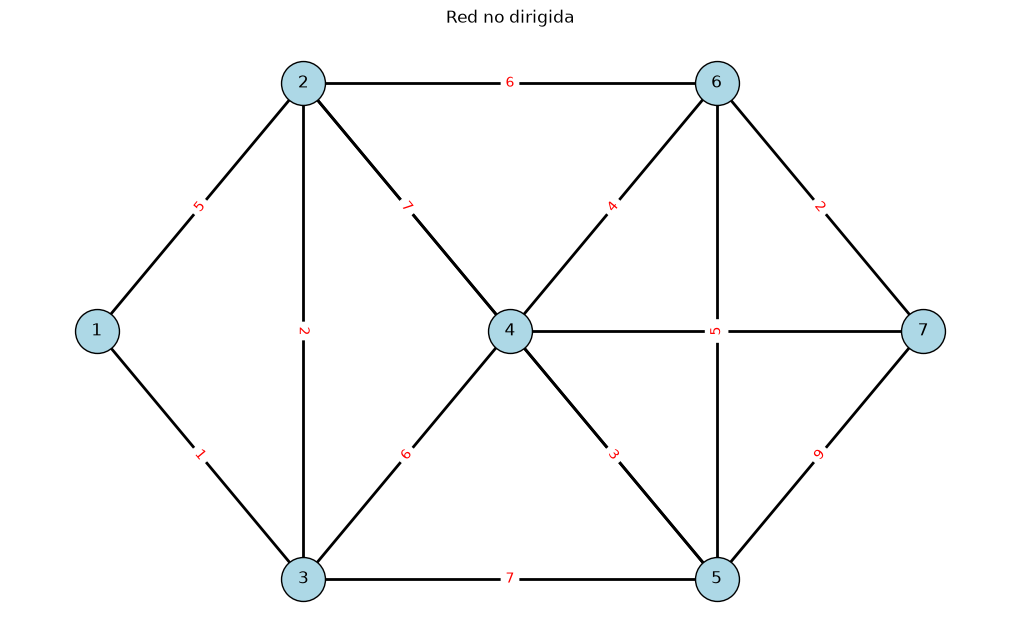

In [5]:
# Posición de los nodos
pos = {
    1: (0, 1),
    2: (1, 2),
    3: (1, 0),
    4: (2, 1),
    5: (3, 0),
    6: (3, 2),
    7: (4, 1)
}

# Pesos de las aristas
pesos = nx.get_edge_attributes(G, "weight")

# Dibujar la red
plt.figure(figsize=(10, 6))

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightblue",
    node_size=1000,
    edgecolors="black",
    width=2,
    font_size=12
)

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=pesos,
    font_color="red"
)

plt.title("Red no dirigida")
plt.axis("off")
plt.show()

In [6]:
# Calcular el árbol de expansión mínima
AEM = nx.minimum_spanning_tree(
    G,
    weight="weight",
    algorithm="kruskal"
)

# Mostrar las aristas
print("Aristas del árbol de expansión mínima:")

for u, v, datos in sorted(AEM.edges(data=True)):
    print(u, "--", v, "Peso:", datos["weight"])

# Mostrar el peso total
peso_total = AEM.size(weight="weight")

print("\nPeso total del árbol:", peso_total)
print("Número de nodos:", AEM.number_of_nodes())
print("Número de aristas:", AEM.number_of_edges())

Aristas del árbol de expansión mínima:
1 -- 3 Peso: 1
2 -- 3 Peso: 2
2 -- 5 Peso: 1
4 -- 5 Peso: 3
4 -- 6 Peso: 4
6 -- 7 Peso: 2

Peso total del árbol: 13.0
Número de nodos: 7
Número de aristas: 6


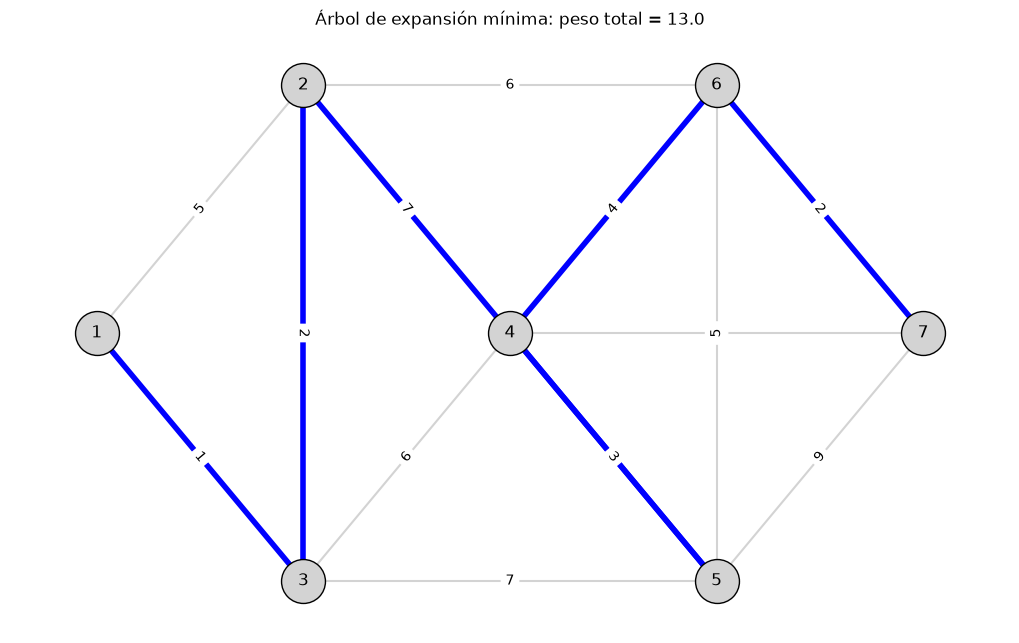

In [8]:
# Dibujar la red no dirigida original en gris
plt.figure(figsize=(10, 6))

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightgray",
    node_size=1000,
    edgecolors="black",
    edge_color="lightgray",
    width=1.5,
    font_size=12
)

# Resaltar el árbol de expansión mínima
nx.draw_networkx_edges(
    AEM, pos,
    edge_color="blue",
    width=4
)

# Poner los pesos
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=pesos
)

plt.title(f"Árbol de expansión mínima: peso total = {peso_total}")
plt.axis("off")
plt.show()

<h2 style="color:#2E75B6;">2. La ruta más corta</h2>

**Definición:** Consiste en encontrar el camino de menor costo entre un nodo de origen y un nodo de destino en una red dirigida.

La función objetivo es:

$$
d(s,t)=\min_{P:s\to t}\sum_{(i,j)\in P}w_{ij}
$$

Donde:

- $s$ es el nodo de origen.
- $t$ es el nodo de destino.
- $w_{ij}$ es el peso del arco que conecta los nodos $i$ y $j$.
- $P$ representa una ruta posible.

Se debe utilizar la función `nx.shortest_path()}` para encontrar la ruta de menor costo.

In [30]:
# Gráfica dirigida
G = nx.DiGraph()

# Arcos y pesos
arcos = [
    (1, 2, 5),
    (1, 3, 1),
    (3, 2, 2),
    (2, 6, 6),
    (6, 2, 7),
    (2, 4, 7),
    (2, 5, 1),
    (3, 4, 6),
    (4, 3, 7),
    (4, 6, 4),
    (4, 7, 6),
    (3, 5, 7),
    (5, 6, 5),
    (6, 7, 2),
    (5, 7, 9),
    (5, 4, 3)
]

# Poner cada arco con su peso
G.add_weighted_edges_from(arcos)

print("Nodos:", list(G.nodes()))
print("Arcos:", G.number_of_edges())

Nodos: [1, 2, 3, 6, 4, 5, 7]
Arcos: 16


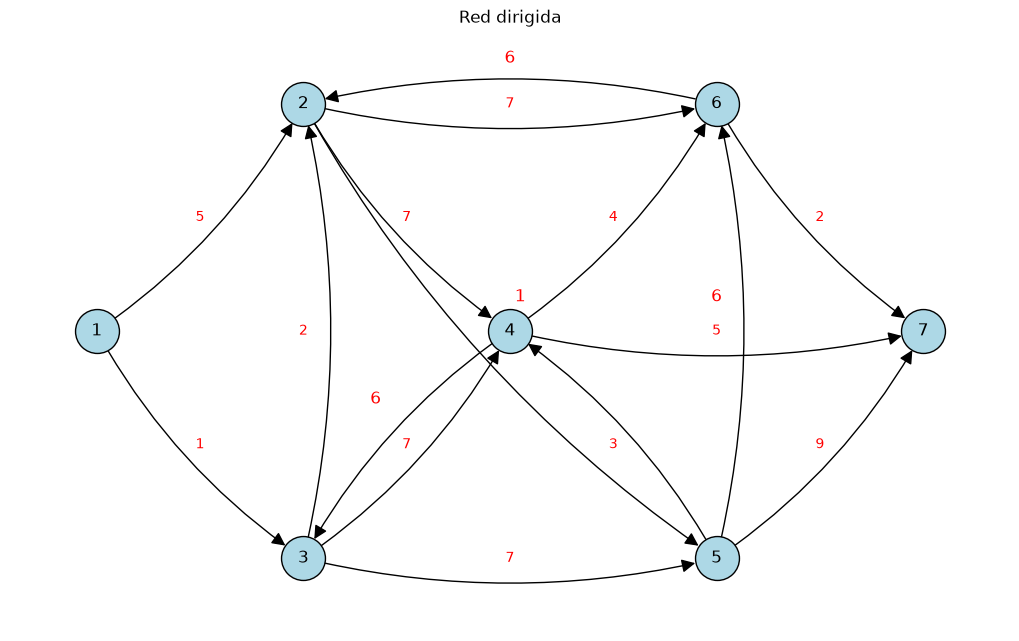

In [31]:
# Poner las posiciones de los nodos
pos = {
    1: (0, 1),
    2: (1, 2),
    3: (1, 0),
    4: (2, 1),
    6: (3, 2),
    5: (3, 0),
    7: (4, 1)
}

# Obtener los pesos de los arcos
pesos = nx.get_edge_attributes(G, "weight")

# Dibujar la red dirigida
plt.figure(figsize=(10, 6))

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightblue",
    node_size=1000,
    edgecolors="black",
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.12",
    font_size=12
)

# Etiquetas que se colocaran manualmente
manuales = {
    (2, 6): (2.0, 2.20),
    (2, 5): (2.05, 1.15),
    (3, 4): (1.35, 0.70),
    (4, 7): (3.0, 1.15)
}

# Dibujar normalmente los demas pesos
pesos_normales = {
    arista: peso
    for arista, peso in pesos.items()
    if arista not in manuales
}

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=pesos_normales,
    font_color="red",
    font_size=12,
    rotate=False
)

# Colocar los cuatro pesos en posiciones separadas
for arista, coordenadas in manuales.items():
    if arista in pesos:
        x, y = coordenadas
        plt.text(
            x, y, str(pesos[arista]),
            color="red",
            fontsize=12,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", edgecolor="none", pad=1)
        )

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=pesos,
    font_color="red",
    label_pos=0.5,
    rotate=False
)

plt.title("Red dirigida")
plt.axis("off")
plt.show()

In [32]:
# Origen y destino
origen = 1
destino = 7

# Ruta de menor costo
ruta = nx.shortest_path(
    G,
    source=origen,
    target=destino,
    weight="weight"
)

# Costo total de la ruta
distancia = nx.shortest_path_length(
    G,
    source=origen,
    target=destino,
    weight="weight"
)

print("Nodo de origen:", origen)
print("Nodo de destino:", destino)
print("Ruta más corta:", ruta)
print("Costo total:", distancia)

Nodo de origen: 1
Nodo de destino: 7
Ruta más corta: [1, 3, 2, 6, 7]
Costo total: 11


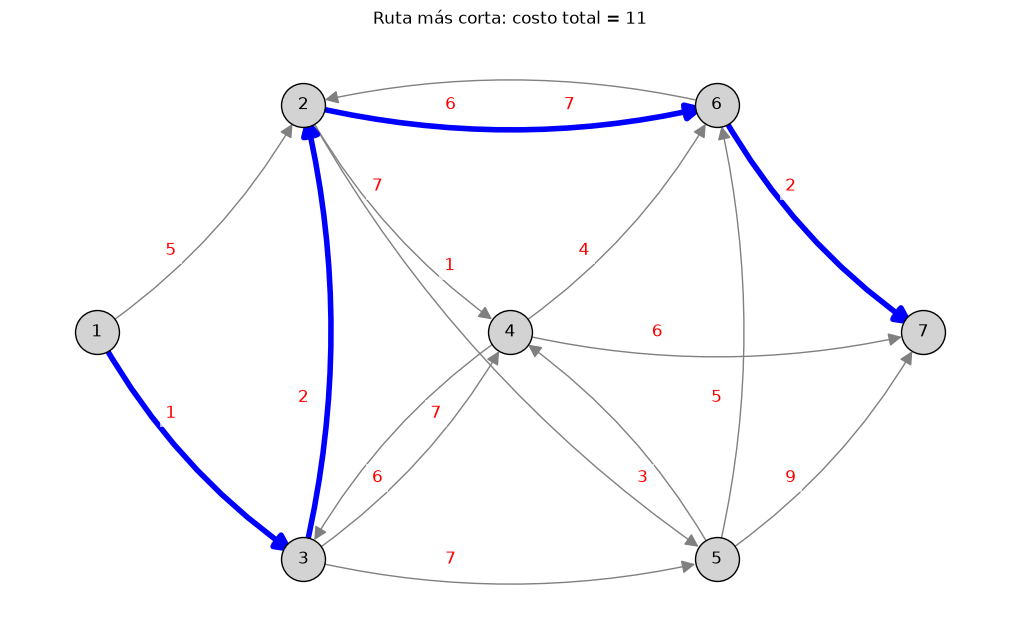

In [35]:
# Actualizar los pesos de la red
pesos = nx.get_edge_attributes(G, "weight")

# Obtener nuevamente la ruta más corta
origen = 1
destino = 7

ruta = nx.shortest_path(
    G, source=origen, target=destino, weight="weight"
)

distancia = nx.shortest_path_length(
    G, source=origen, target=destino, weight="weight"
)

# Poner los arcos de la ruta encontrada
arcos_ruta = list(zip(ruta[:-1], ruta[1:]))

# Dibujar la red completa
plt.figure(figsize=(10, 6))

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightgray",
    node_size=1000,
    edgecolors="black",
    edge_color="gray",
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.12",
    font_size=12
)

# Resaltar la ruta más corta
nx.draw_networkx_edges(
    G, pos,
    edgelist=arcos_ruta,
    edge_color="blue",
    width=4,
    arrows=True,
    arrowsize=25,
    connectionstyle="arc3,rad=0.12"
)

# Poner los pesos de las aristas
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=pesos,
    font_color="red",
    font_size=12,
    label_pos=0.35,
    rotate=False,
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.7
    )
)

plt.title(f"Ruta más corta: costo total = {distancia}")
plt.axis("off")
plt.show()

<h2 style="color:#2E75B6;">3. Flujo máximo</h2>

**Definición:** Consiste en determinar la mayor cantidad de flujo que puede enviarse desde un nodo de origen hasta un nodo de destino, respetando la capacidad de cada arco.Además, se debe considerar el nodo 1 como el origen y el nodo 5 como el destino.

La función objetivo es:

$$
\max v
$$

Sujeto a restricciones de capacidad:

$$
0 \leq f_{ij} \leq c_{ij}
$$

Y a la conservación del flujo en los nodos intermedios:

$$
\sum_j f_{ji}=\sum_j f_{ij}
$$

Donde $f_{ij}$ es el flujo enviado por el arco $(i,j)$ y $c_{ij}$ es su capacidad.

Se debe utilizar la función `nx.maximum_flow()`.

In [59]:
# Crear la red dirigida
G = nx.DiGraph()

# Arcos y sus capacidades
arcos = [
    (1, 3, 14),
    (3, 1, 0),
    (1, 5, 4),
    (5, 1, 0),
    (1, 2, 8),
    (2, 1, 0),
    (2, 3, 5),
    (3, 2, 10),
    (3, 5, 10),
    (5, 3, 0),
    (3, 4, 9),
    (4, 3, 7),
    (2, 4, 7),
    (4, 2, 6),
    (2, 5, 6),
    (5, 2, 0),
    (4, 5, 5),
    (5, 4, 0)
]

# Unir las capacidades como atributo
for u, v, capacidad in arcos:
    G.add_edge(u, v, capacity=capacidad)

print("Nodos de la red:", list(G.nodes()))
print("Número de arcos:", G.number_of_edges())

Nodos de la red: [1, 3, 5, 2, 4]
Número de arcos: 18


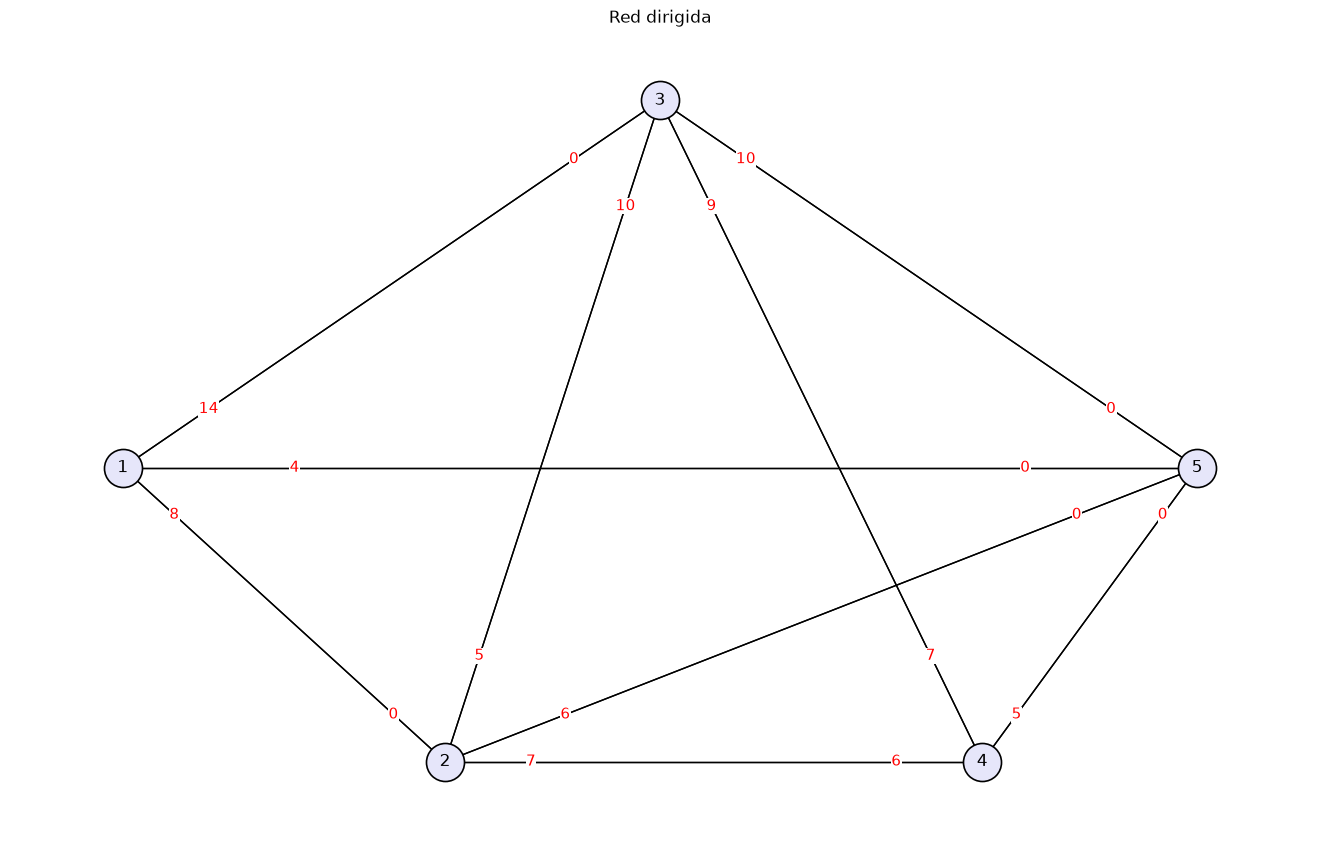

In [60]:
# Posiciones
pos = {
    1: (-1, 0),
    2: (-0.4, -0.8),
    3: (0, 1),
    4: (0.6, -0.8),
    5: (1, 0)
}

# Capacidades
capacidades = nx.get_edge_attributes(G, "capacity")

plt.figure(figsize=(13, 8))

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lavender",
    node_size=750,
    edgecolors="black",
    linewidths=1.2,
    arrows=False,
    font_size=12,
    font_color="black"
)

# Calcular la posición de las etiquetas
alpha = 0.16

etiquetas_pos = {}
for u, v in capacidades.keys():
    x1, y1 = pos[u]
    x2, y2 = pos[v]

    x_etiqueta = x1 + alpha * (x2 - x1)
    y_etiqueta = y1 + alpha * (y2 - y1)

    etiquetas_pos[(u, v)] = (x_etiqueta, y_etiqueta)

# Dibujar cada capacidad en su posición
for arco, capacidad in capacidades.items():
    x, y = etiquetas_pos[arco]
    plt.text(
        x,
        y,
        str(capacidad),
        color="red",  
        fontsize=11,
        ha="center",
        va="center",
        bbox=dict(facecolor="white", edgecolor="none", pad=0.2),
        zorder=10,
    )

plt.title("Red dirigida")
plt.axis("off")
plt.show()

In [61]:
# Origen y destino
origen = 1
destino = 5

# Flujo máximo
flujo_maximo, flujos = nx.maximum_flow(
    G,
    origen,
    destino,
    capacity="capacity"
)

print("Nodo de origen:", origen)
print("Nodo de destino:", destino)
print("Flujo máximo:", flujo_maximo)

print("\nFlujo enviado por cada arco:")

for u, destinos in flujos.items():
    for v, flujo in destinos.items():
        if flujo > 0:
            print(
                f"{u} -> {v}: {flujo} "
                f"de {G[u][v]['capacity']}"
            )

Nodo de origen: 1
Nodo de destino: 5
Flujo máximo: 25

Flujo enviado por cada arco:
1 -> 3: 13 de 14
1 -> 5: 4 de 4
1 -> 2: 8 de 8
3 -> 5: 10 de 10
3 -> 4: 5 de 9
2 -> 3: 2 de 5
2 -> 5: 6 de 6
4 -> 5: 5 de 5


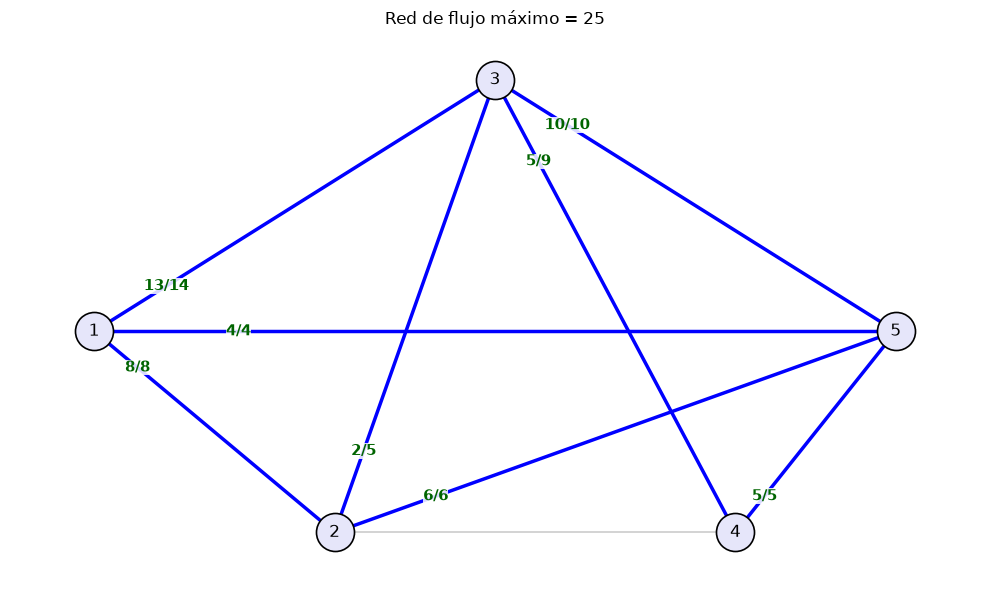

In [76]:
plt.figure(figsize=(10, 6))

# Aristas no dirigidas que llevan flujo real
arcos_con_flujo_positivo = []
for u in G.nodes():
    for v in G[u]:
        if flujos[u][v] > 0:
            # Añadimos la arista sin importar el orden para dibujarla
            arco = (u, v) if (u, v) in G.edges() else (v, u)
            if arco not in arcos_con_flujo_positivo:
                arcos_con_flujo_positivo.append(arco)

arcos_sin_flujo = [e for e in G.edges() if e not in arcos_con_flujo_positivo]

# Dibujar la red base
nx.draw_networkx_nodes(
    G, pos,
    node_color="lavender",
    node_size=750,
    edgecolors="black",
    linewidths=1.2
)
nx.draw_networkx_labels(G, pos, font_size=12, font_color="black")

# Dibujar la red base 
nx.draw_networkx_edges(
    G, pos,
    edgelist=arcos_sin_flujo,
    edge_color="lightgray",
    width=1.2,
    arrows=False
)

# Dibujar la red de flujo máximo
nx.draw_networkx_edges(
    G, pos,
    edgelist=arcos_con_flujo,
    edge_color="blue",
    width=2.5,
    arrows=False
)

# Posición de las etiquetas
alpha = 0.18

for u, v in G.edges():
    flujo_actual = flujos[u][v]
    capacidad_total = G[u][v]["capacity"]
    
    if flujo_actual > 0:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            
            x = x1 + alpha * (x2 - x1)
            y = y1 + alpha * (y2 - y1)

            plt.text(
                x,
                y,
                f"{flujo_actual}/{capacidad_total}",
                color="darkgreen" if es_activo else "gray",
                fontsize=11,
                fontweight="bold" if es_activo else "normal",
                ha="center",
                va="center",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.15, alpha=0.85),
                zorder=10,
            )

plt.title(f"Red de flujo máximo = {flujo_maximo}")
plt.axis("off")
plt.tight_layout()
plt.show()